# Practice 3: Exercise 1 — Zero-Shot Sentiment Analysis & Dataset EDA

## Overview & Purpose
This notebook demonstrates and analyzes Exercise 1 of Practice 3:
1. **Dataset Exploratory Data Analysis (EDA):** Class balance (50/50 ratio) and review length distribution on [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb).
2. **Tokenization Breakdown:** Inspecting tokenization details (tokens, token IDs, attention mask) with [`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
3. **Zero-Shot Sentiment Pipeline Demo:** Running sentiment analysis on sample sentences.
4. **Baseline Evaluation Artifacts:** Visualizing baseline 5W1H metrics, ROC-AUC score (`0.9587`), and PyTorch TensorBoard log locations (produced by [`src/experiments/baseline_imdb_sentiment.py`](../src/experiments/baseline_imdb_sentiment.py)).

> **Note:** Per project rules ([`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md)), notebooks do not run long evaluation loops — they load persisted JSON artifacts and plots produced by scripts.

## Roadmap Table
| Step | Description | What it does | Import path |
|:---:|:---|:---|:---|
| 1 | Dataset EDA & Visualizations | Load dataset stats, label distribution, and review length plots | [`src/data/eda_imdb.py`](../src/data/eda_imdb.py) |
| 2 | Tokenization Breakdown | Demonstrate tokenization, input IDs, and attention mask | `transformers.AutoTokenizer` |
| 3 | Zero-Shot Pipeline Demo | Run sentiment analysis pipeline on sample sentences | [`src/experiments/baseline_imdb_sentiment.py`](../src/experiments/baseline_imdb_sentiment.py) |
| 4 | Load Baseline & ROC Artifacts | Display persisted 5W1H metrics and ROC-AUC curve plot | [`experiments/results/baseline_imdb_sentiment.json`](../experiments/results/baseline_imdb_sentiment.json) |

---

## References
- **Rulebase:** [`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md), [`RESULTS_REPORTING.md`](../agents/rules/RESULTS_REPORTING.md), [`NOTEBOOK_HEADER_CONVENTION.md`](../agents/rules/NOTEBOOK_HEADER_CONVENTION.md)
- **EDA Script Entry Point:** [`src/data/eda_imdb.py`](../src/data/eda_imdb.py)
- **Baseline Script Entry Point:** [`src/experiments/baseline_imdb_sentiment.py`](../src/experiments/baseline_imdb_sentiment.py)
- **Persisted Artifacts:** [`experiments/results/baseline_imdb_sentiment.json`](../experiments/results/baseline_imdb_sentiment.json), [`experiments/results/imdb_dataset_eda.json`](../experiments/results/imdb_dataset_eda.json)
- **Hugging Face Model:** [`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english)
- **Hugging Face Dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb)


In [1]:
import json
import time
from pathlib import Path
import numpy as np
import torch
from IPython.display import Image, display
from transformers import AutoTokenizer, pipeline

PROJECT_ROOT = Path("..").resolve()
device_id = 0 if torch.cuda.is_available() else -1
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Device:       {device_name} (device_id={device_id})")


Project Root: /home/bush/Desktop/Deeplearning_Course_UTH
Device:       NVIDIA GeForce RTX 3050 Laptop GPU (device_id=0)


 IMDB DATASET EXPLORATORY DATA ANALYSIS (EDA)
Train Split: 25,000 samples (50% Neg, 50% Pos)
Test Split:  25,000 samples (50% Neg, 50% Pos)
Word Count Stats (Train): Mean=233.8, Median=174, 95th Pct=598, Max=2470

--- Class Balance Distribution ---


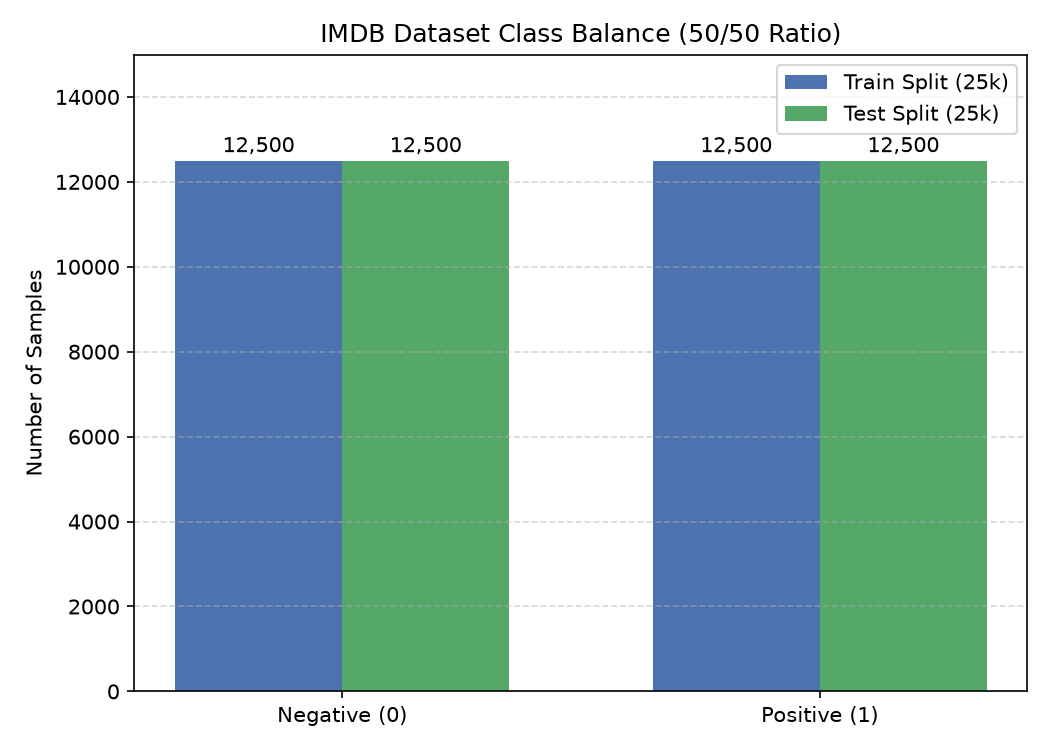


--- Review Length Distribution (Word Count) ---


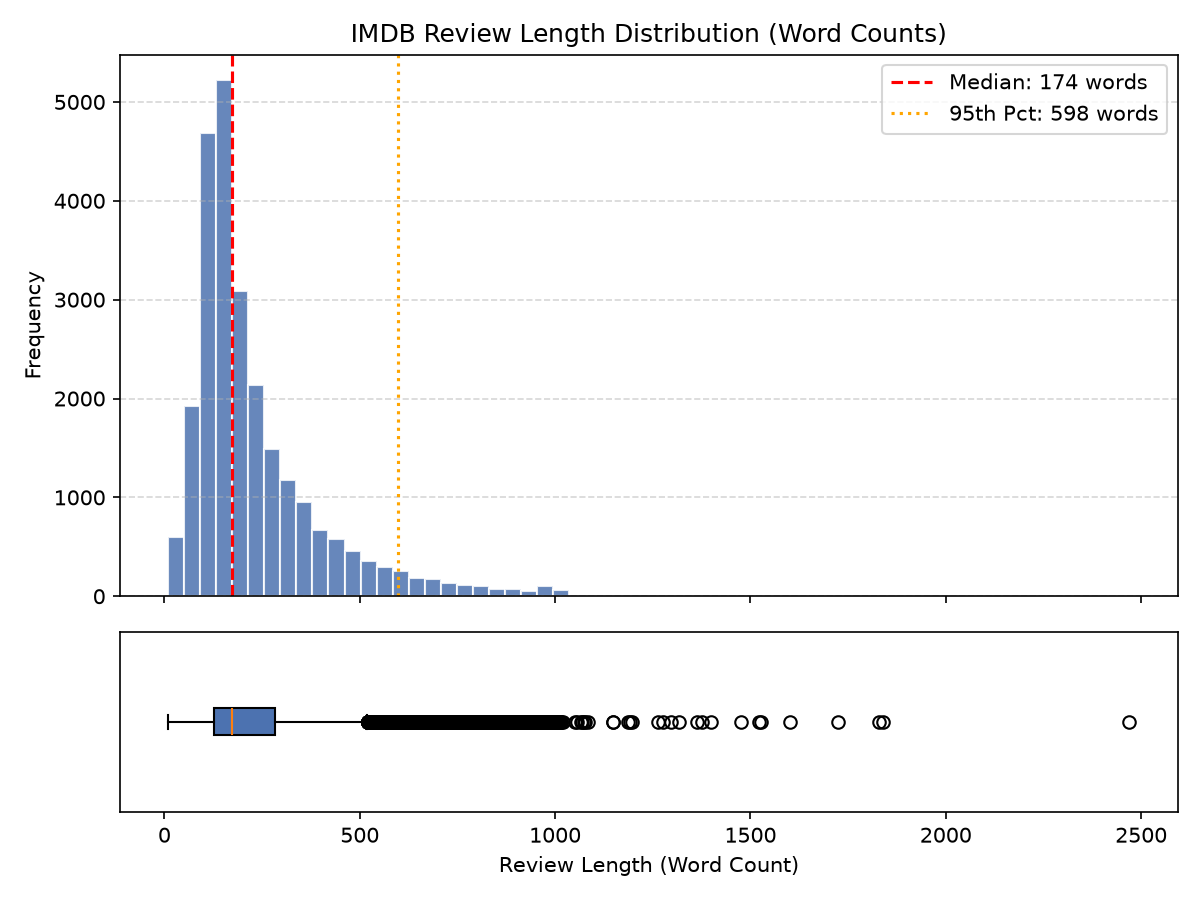

In [2]:
# Step 1: Load and Display IMDB Dataset EDA Visualizations
eda_json_path = PROJECT_ROOT / "experiments" / "results" / "imdb_dataset_eda.json"

if not eda_json_path.exists():
    print("Running EDA script to generate statistics and plots...")
    from src.data.eda_imdb import run_imdb_eda
    stats = run_imdb_eda()
else:
    with open(eda_json_path, "r", encoding="utf-8") as f:
        stats = json.load(f)

print("=" * 65)
print(" IMDB DATASET EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 65)
print(f"Train Split: {stats['splits']['train']['total']:,} samples (50% Neg, 50% Pos)")
print(f"Test Split:  {stats['splits']['test']['total']:,} samples (50% Neg, 50% Pos)")
l_stats = stats['review_length_word_count_stats']
print(f"Word Count Stats (Train): Mean={l_stats['mean']:.1f}, Median={l_stats['median']:.0f}, 95th Pct={l_stats['pct_95']:.0f}, Max={l_stats['max']}")
print("=" * 65)

# Display Class Balance & Review Length Plots
print("\n--- Class Balance Distribution ---")
display(Image(filename=str(PROJECT_ROOT / "experiments" / "plots" / "imdb_label_distribution.png")))

print("\n--- Review Length Distribution (Word Count) ---")
display(Image(filename=str(PROJECT_ROOT / "experiments" / "plots" / "imdb_review_length_distribution.png")))


In [3]:
# Step 2: Exercise 1 Tokenization Breakdown
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_text = "The movie was thrilling and visually stunning!"
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
encoding = tokenizer(sample_text)

print(f"Sample Input:   '{sample_text}'")
print(f"Tokens:         {tokens}")
print(f"Token IDs:      {token_ids}")
print(f"Input IDs:      {encoding['input_ids']}")
print(f"Attention Mask: {encoding['attention_mask']}")


Sample Input:   'The movie was thrilling and visually stunning!'
Tokens:         ['the', 'movie', 'was', 'thrilling', 'and', 'visually', 'stunning', '!']
Token IDs:      [1996, 3185, 2001, 26162, 1998, 17453, 14726, 999]
Input IDs:      [101, 1996, 3185, 2001, 26162, 1998, 17453, 14726, 999, 102]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [4]:
# Step 3: Hugging Face Zero-Shot Sentiment Pipeline
clf = pipeline("sentiment-analysis", model=model_name, device=device_id)

test_sentences = [
    "The movie was thrilling and visually stunning!",
    "The plot was boring and predictable, a waste of time.",
    "It had incredible visuals, but the story felt completely hollow."
]

print("--- Zero-Shot Sentiment Predictions ---")
for text in test_sentences:
    t0 = time.time()
    res = clf(text)[0]
    dt = (time.time() - t0) * 1000.0
    print(f'Input:      "{text}"')
    print(f"Prediction: Label={res['label']}, Score={res['score']:.4f} (latency: {dt:.2f} ms)\n")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

--- Zero-Shot Sentiment Predictions ---


Input:      "The movie was thrilling and visually stunning!"
Prediction: Label=POSITIVE, Score=0.9999 (latency: 283.24 ms)

Input:      "The plot was boring and predictable, a waste of time."
Prediction: Label=NEGATIVE, Score=0.9998 (latency: 5.82 ms)

Input:      "It had incredible visuals, but the story felt completely hollow."
Prediction: Label=NEGATIVE, Score=0.9988 (latency: 5.56 ms)



 PERSISTED 5W1H METADATA & BASELINE EVALUATION RESULTS
Who:   Learner & AI Coding Agent
What:  Exercise 1 Zero-Shot Sentiment Analysis Baseline
When:  2026-08-12T08:11:36.163852
Where: Repo branch feature/ex1-sentiment-baseline (GPU)
Why:   Establish baseline accuracy floor on IMDB for Practice 3 Exercise 1 & 2 comparison
How:   Hugging Face pipeline with pretrained model 'distilbert-base-uncased-finetuned-sst-2-english'

--- Metric Summary ---
Evaluated Test Samples:  25,000
Majority-Class Floor:     50.00%
Zero-Shot Model Accuracy: 89.07%
Zero-Shot ROC-AUC Score:  0.9587
Total Evaluation Time:   274.77 s
TensorBoard Log Dir:     experiments/runs/baseline_zero_shot/tensorboard

--- Zero-Shot ROC Curve Plot ---


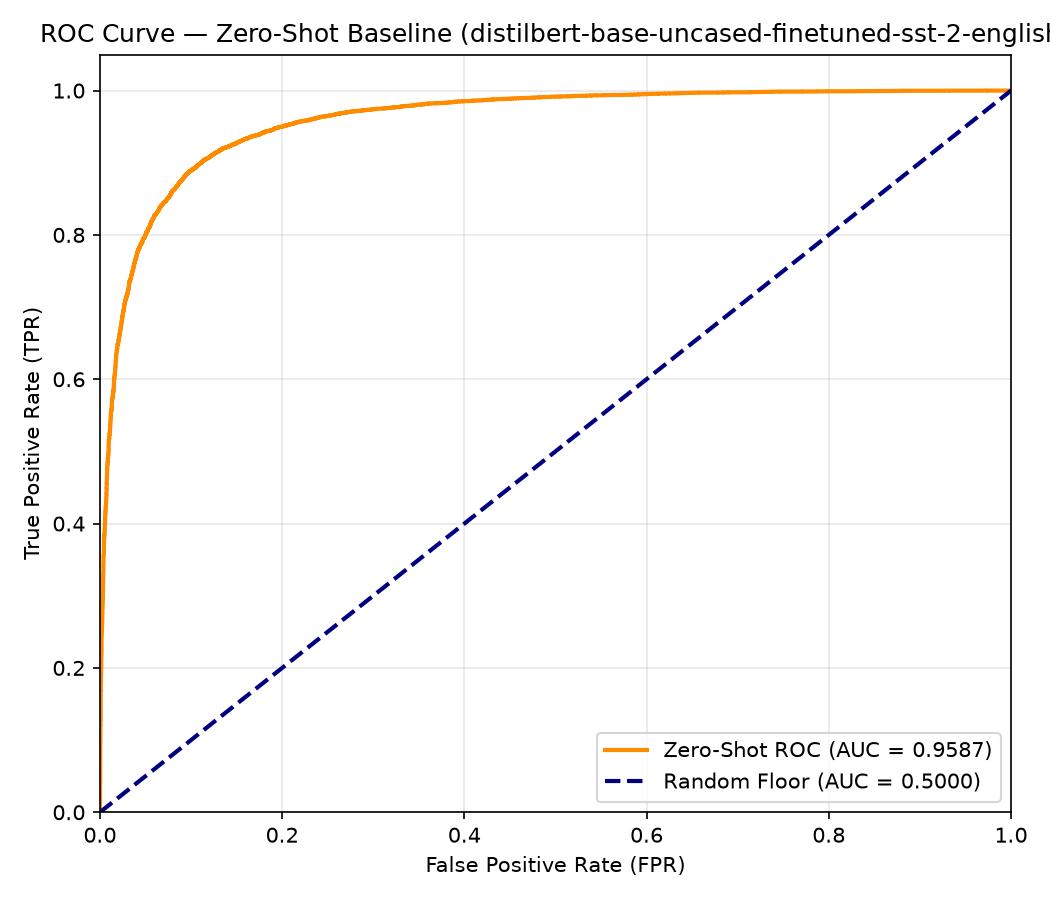

In [5]:
# Step 4: Load Persisted Baseline Results & ROC Curve Visualization
artifact_path = PROJECT_ROOT / "experiments" / "results" / "baseline_imdb_sentiment.json"

if not artifact_path.exists():
    print(f"Artifact not found at {artifact_path}. Please run:")
    print("  python -m src.experiments.baseline_imdb_sentiment --eval-imdb")
else:
    with open(artifact_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    print("=" * 65)
    print(" PERSISTED 5W1H METADATA & BASELINE EVALUATION RESULTS")
    print("=" * 65)
    meta = data["metadata_5w1h"]
    print(f"Who:   {meta['who']}")
    print(f"What:  {meta['what']}")
    print(f"When:  {meta['when']}")
    print(f"Where: {meta['where']}")
    print(f"Why:   {meta['why']}")
    print(f"How:   {meta['how']}")
    
    print("\n--- Metric Summary ---")
    eval_m = data["evaluation"]
    print(f"Evaluated Test Samples:  {eval_m['num_test_samples']:,}")
    print(f"Majority-Class Floor:     {eval_m['majority_class_accuracy'] * 100.0:.2f}%")
    print(f"Zero-Shot Model Accuracy: {eval_m['zero_shot_accuracy'] * 100.0:.2f}%")
    if "zero_shot_roc_auc" in eval_m and not np.isnan(eval_m["zero_shot_roc_auc"]):
        print(f"Zero-Shot ROC-AUC Score:  {eval_m['zero_shot_roc_auc']:.4f}")
    print(f"Total Evaluation Time:   {eval_m['eval_time_seconds']:.2f} s")
    print(f"TensorBoard Log Dir:     {eval_m.get('tensorboard_log_dir', 'N/A')}")
    print("=" * 65)

roc_plot_path = PROJECT_ROOT / "experiments" / "plots" / "baseline_zero_shot_roc_curve.png"
if roc_plot_path.exists():
    print("\n--- Zero-Shot ROC Curve Plot ---")
    display(Image(filename=str(roc_plot_path)))
